# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [22]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import geopandas as gpd


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [23]:
# Load data
data = pd.read_csv('data/bcn_noise_regre_ml_dataset_filtered.csv')
print(data)

                         road_id  noise_day  noise_evening  noise_night  \
0      13859746870_13859746860_0         55             55           50   
1       13798851565_8465472214_0         50             50           45   
2       4538123419_13734642240_0         65             65           60   
3        13845167536_253790691_0         55             55           50   
4      13859746847_13859746858_0         55             55           50   
...                          ...        ...            ...          ...   
12620    8930700699_9446738721_0         55             55           50   
12621    8930700699_9446689099_0         55             55           50   
12622     559052401_3358594835_0         70             65           60   
12623     9446738720_553047568_0         55             55           50   
12624      553047566_553047568_0         55             55           50   

       road_category  dist_to_trunk  dist_to_primary  dist_to_secondary  \
0                  5    

In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12625 entries, 0 to 12624
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12625 non-null  str    
 1   noise_day              12625 non-null  int64  
 2   noise_evening          12625 non-null  int64  
 3   noise_night            12625 non-null  int64  
 4   road_category          12625 non-null  int64  
 5   dist_to_trunk          12625 non-null  float64
 6   dist_to_primary        12625 non-null  float64
 7   dist_to_secondary      12625 non-null  float64
 8   dist_to_tertiary       12625 non-null  float64
 9   dist_to_residential    12625 non-null  float64
 10  dist_to_living_street  12625 non-null  float64
 11  signals                12625 non-null  float64
 12  transport              12625 non-null  float64
 13  pois                   12625 non-null  float64
 14  width                  12625 non-null  float64
 15  betweenness  

## Predicting Street-level Noise


### Select features (X)

In [25]:
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night'])
X

,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,5,213.093,509.628,1110.052,188.355,0.000,385.613,0.053,0.000,0.107,50.000,0.000,0.000,0.000,0.808,3.349,0.000,0.000
1,5,173.078,1621.681,2110.530,351.777,0.000,117.669,0.000,0.014,0.000,20.006,0.000,0.000,0.000,0.741,0.000,0.000,0.000
2,3,904.119,947.155,0.000,167.027,0.000,19.810,0.167,0.000,0.295,50.000,0.010,0.000,0.000,0.831,8.619,0.000,0.000
3,5,1872.178,607.144,967.746,0.000,0.000,49.110,0.000,0.054,0.000,50.000,0.004,0.000,0.000,0.737,25.170,0.000,0.000
4,5,230.461,497.476,1128.775,207.822,0.000,402.271,0.076,0.000,0.152,50.000,0.000,0.000,0.000,0.807,7.945,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12620,5,1166.465,3718.930,504.637,2.622,0.000,857.337,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.809,15.246,100.000,0.000
12621,5,1164.506,3718.930,504.637,5.402,0.000,857.337,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.808,15.278,100.000,0.000
12622,4,2094.224,1392.526,0.000,0.000,22.953,40.225,0.070,0.009,0.009,34.152,0.002,0.000,0.000,0.847,3.313,0.000,0.000
12623,5,1185.946,3731.357,511.507,0.000,0.000,852.508,0.000,0.000,0.000,50.000,0.001,0.000,0.000,0.812,16.276,100.000,0.000


### Standard scaling

In [26]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

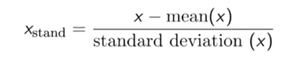

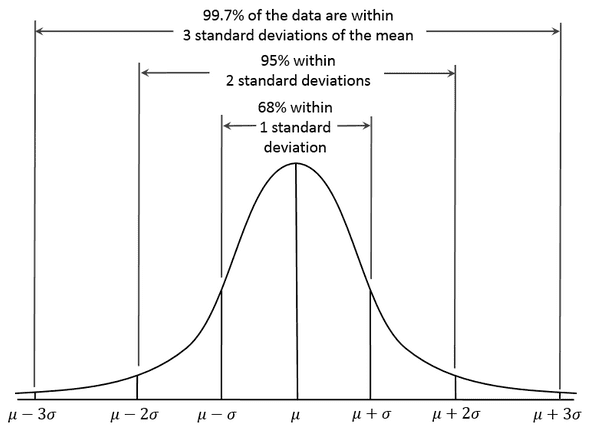

In [27]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.3690705 , -1.5008946 , -0.33080231, ..., -0.29189472,
        -0.19973742, -0.14511338],
       [ 0.3690705 , -1.54679284,  1.09331611, ..., -0.48362596,
        -0.19973742, -0.14511338],
       [-1.66033503, -0.70827508,  0.22950335, ...,  0.00978711,
        -0.19973742, -0.14511338],
       ...,
       [-0.64563226,  0.65679893,  0.79985558, ..., -0.29397184,
        -0.19973742, -0.14511338],
       [ 0.3690705 , -0.3850136 ,  3.79501228, ...,  0.44808866,
         6.16603024, -0.14511338],
       [-0.64563226, -0.3850136 ,  3.79501228, ...,  0.50331587,
         6.16603024, -0.14511338]], shape=(12625, 18))

In [28]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(12625, 18)
             0         1         2         3         4         5         6   \
count 12625.000 12625.000 12625.000 12625.000 12625.000 12625.000 12625.000   
mean      0.000    -0.000    -0.000     0.000     0.000    -0.000    -0.000   
std       1.000     1.000     1.000     1.000     1.000     1.000     1.000   
min      -3.690    -1.745    -0.983    -0.900    -0.851    -0.320    -0.545   
25%      -0.646    -0.822    -0.695    -0.744    -0.851    -0.320    -0.545   
50%       0.369    -0.043    -0.287    -0.292    -0.252    -0.320    -0.268   
75%       0.369     0.842     0.389     0.399     0.457    -0.320     0.099   
max       1.384     2.608     4.997     5.585     5.846    17.839     8.592   

             7         8         9         10        11        12        13  \
count 12625.000 12625.000 12625.000 12625.000 12625.000 12625.000 12625.000   
mean      0.000     0.000    -0.000     0.000    -0.000    -0.000    -0.000   
std       1.000     1.000     1.000    

### Define dependant variable (Y)

In [29]:
# Define the dependant variable / target to predict
y_reg = data.noise_day
print(y_reg)

0        55
1        50
2        65
3        55
4        55
         ..
12620    55
12621    55
12622    70
12623    55
12624    55
Name: noise_day, Length: 12625, dtype: int64


### Split data

In [30]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [31]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(10100, 18)
(10100,)
(2525, 18)
(2525,)


## Linear Regression

### Train model

In [32]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

score_linear = model.score(X_test, y_test)

0.46448144004332026
0.4734606865035563


In [33]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [-1.57871008  0.30207546 -1.02745548 -0.42902844 -0.78260892  0.27543786
  0.6984714   1.00081881  0.49083283  0.20700739  0.10803918  0.39714699
  1.198812   -0.21889192  1.65545621 -0.31591284  0.41201507  0.06891624] intercetp 59.74420442437499


### Inspect results

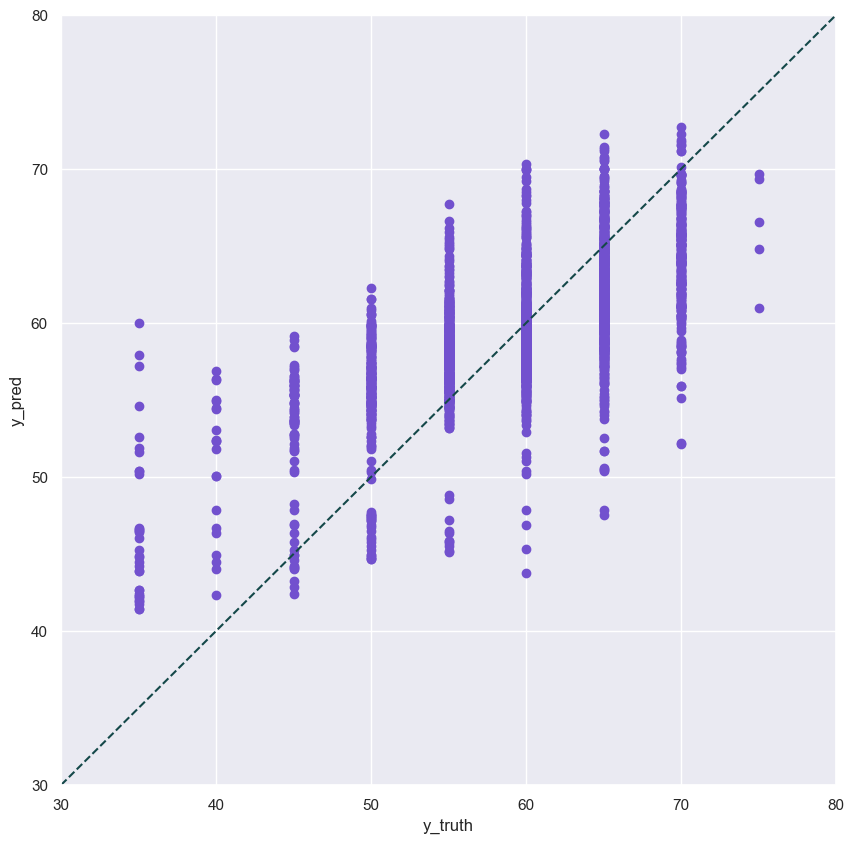

In [34]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_xg'] = y_test - y_pred

plt.scatter(y_test,y_pred, color = '#7251ceff')

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.xlim(30, 80)
plt.ylim(30, 80)
plt.axline((0,0), slope = 1, ls="--", color = "#144849ff")

In [35]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 2525 entries, 10679 to 1845
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                2525 non-null   str    
 1   noise_day              2525 non-null   int64  
 2   noise_evening          2525 non-null   int64  
 3   noise_night            2525 non-null   int64  
 4   road_category          2525 non-null   int64  
 5   dist_to_trunk          2525 non-null   float64
 6   dist_to_primary        2525 non-null   float64
 7   dist_to_secondary      2525 non-null   float64
 8   dist_to_tertiary       2525 non-null   float64
 9   dist_to_residential    2525 non-null   float64
 10  dist_to_living_street  2525 non-null   float64
 11  signals                2525 non-null   float64
 12  transport              2525 non-null   float64
 13  pois                   2525 non-null   float64
 14  width                  2525 non-null   float64
 15  betweenness     

In [36]:
data_test['noisePred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_reg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['road_id']
).interactive()

alt.Chart(...)

## XGBoost

### Train with new model

In [37]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))
score_xgb = model.score(X_test, y_test)

0.9164062738418579
0.7045419812202454


### Inspect results

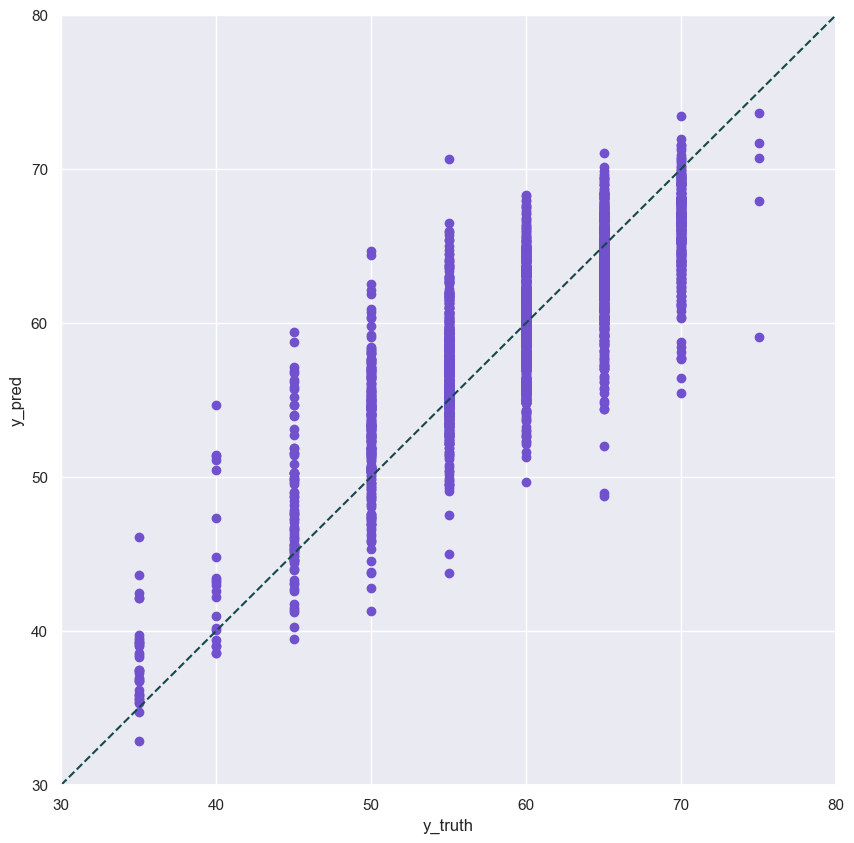

In [38]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred, color = '#7251ceff')

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.xlim(30, 80)
plt.ylim(30, 80)
plt.axline((0,0), slope = 1, ls="--", color = "#144849ff")

In [41]:
data_test['noisePred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['road_id']
).interactive()

alt.Chart(...)

## Compare results

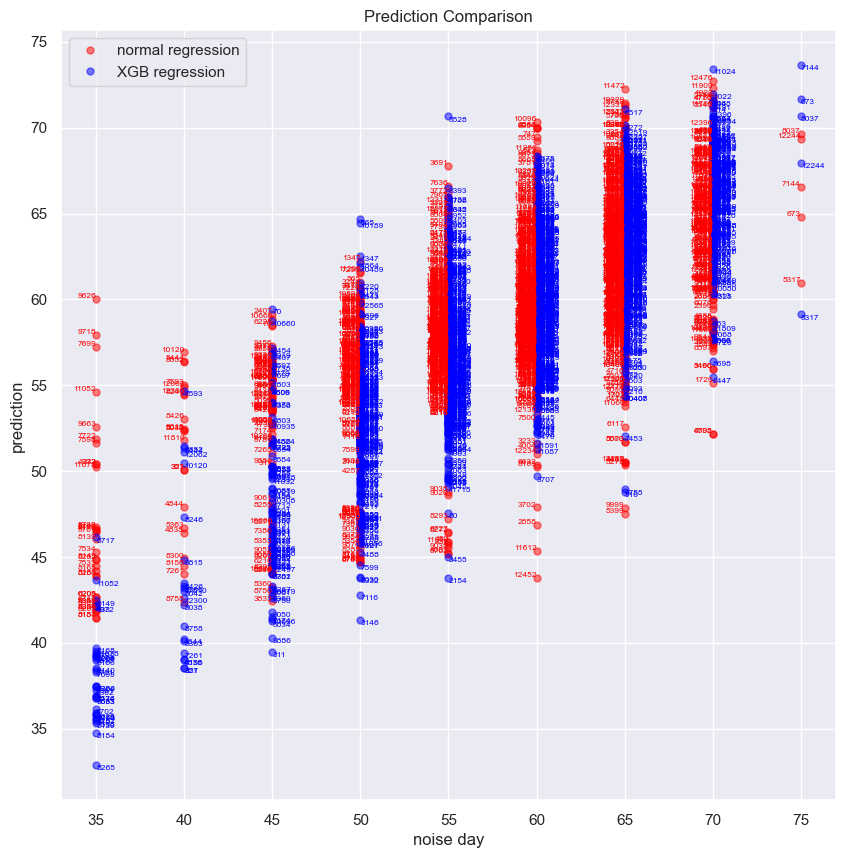

In [42]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('noise day')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()

## Random Forest

In [43]:

from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    random_state=42,
    max_depth=None,         
    min_samples_leaf=1,    
    min_samples_split=2,   
)

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9616287667523356
0.7291167502667657


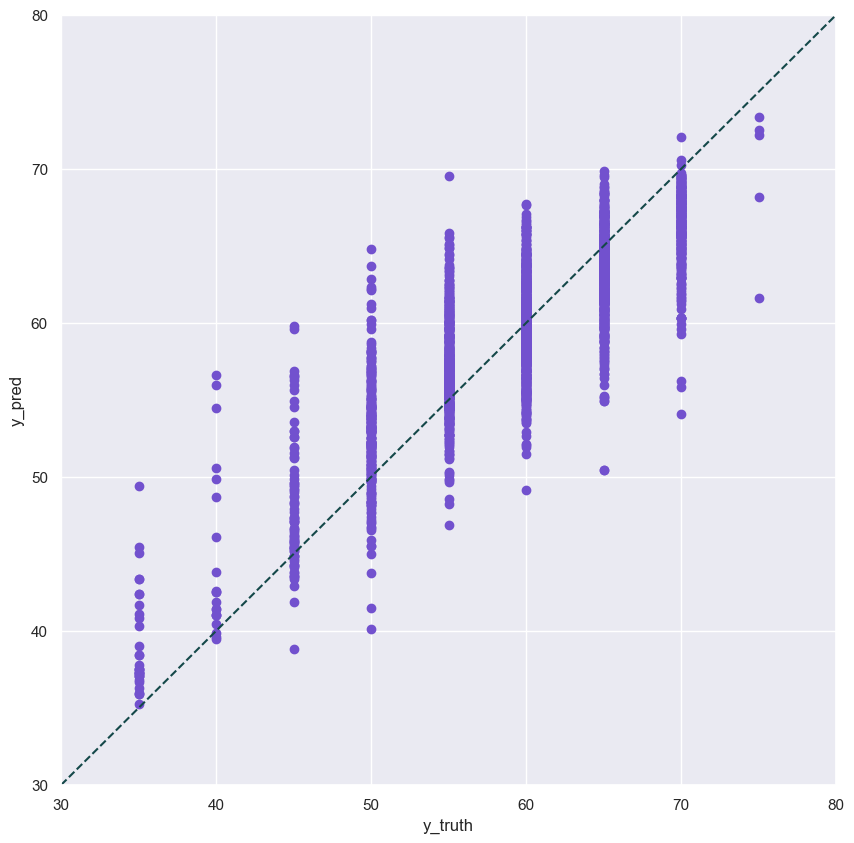

In [44]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
plt.scatter(y_test,y_pred, color = '#7251ceff')
plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.xlim(30, 80)
plt.ylim(30, 80)
plt.axline((0,0), slope = 1, ls="--", color = "#144849ff")

### Inspect results

In [51]:
data_test["y_pred"]= y_pred
data_test["y_truth"]= y_test
data_test["y_diff"]= y_pred - y_test

In [52]:
data_test['noisePred_xg'] = y_pred
alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['road_id']
).interactive()

alt.Chart(...)

### See results in interactive map

In [53]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

In [54]:
m = merged_gdf.to_crs(epsg=4326).explore(
    column='y_diff',
    cmap='RdBu',
    tiles='CartoDB positron',
    tooltip=['road_id', 'y_diff', 'y_pred', 'y_truth', 'highway'],
    legend=True,
)
m.save("map_y_diff.html")

import webbrowser, os
webbrowser.open('file://' + os.path.realpath("map_y_diff.html"))

True